In [1]:
import pandas as pd
import optuna
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Reduced Dataset.csv')

# Drop diseases with less than 1000 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 750].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 114
Number of rows left: 114312


In [3]:
# Apply SMOTE for class balancing in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the new class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("Number of remaining classes in training set:", len(np.unique(y_train_resampled)))
print("Number of rows in the resampled training set:", len(X_train_resampled))

# Feature scaling (VERY IMPORTANT for KNN)
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

Class distribution after SMOTE:
20     1002
9      1002
66     1002
80     1002
1      1002
       ... 
40     1002
106    1002
54     1002
102    1002
88     1002
Name: count, Length: 114, dtype: int64
Number of remaining classes in training set: 114
Number of rows in the resampled training set: 114228


In [4]:
# Optuna optimization function
def objective(trial):
    # Define the hyperparameters to tune for KNN
    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)  # p=1 (Manhattan), p=2 (Euclidean)

    # Create KNeighborsClassifier with hyperparameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p
    )

    # Perform cross-validation (using 5-fold by default)
    score = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
    accuracy = score.mean()

    # Log the hyperparameters and accuracy for this trial
    print(f"Trial {trial.number}: n_neighbors={n_neighbors}, weights={weights}, p={p}, Accuracy={accuracy:.4f}")

    return accuracy

In [6]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize', 
    study_name="knn_diseases_symptoms_dropextremelymore750withSMOTE_study",
    storage=r"sqlite:///C:/Users/khiew/Downloads/knn.db", 
    load_if_exists=True
)

# Optimize the study with your objective function, adjust n_trials as needed
study.optimize(objective, n_trials=20)

# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

# After finding the best hyperparameters, you can fit the final KNN model on resampled data
best_params = study.best_trial.params
final_model = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    p=best_params['p']
)
final_model.fit(X_train_resampled, y_train_resampled)

# Evaluate on test set
y_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")


[I 2025-04-27 16:29:16,222] A new study created in RDB with name: knn_diseases_symptoms_dropextremelymore750withSMOTE_study
[I 2025-04-27 16:29:26,881] Trial 0 finished with value: 0.4566481531819425 and parameters: {'n_neighbors': 43, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.4566481531819425.


Trial 0: n_neighbors=43, weights=uniform, p=2, Accuracy=0.4566


[I 2025-04-27 16:29:38,387] Trial 1 finished with value: 0.46891312595433055 and parameters: {'n_neighbors': 32, 'weights': 'distance', 'p': 2}. Best is trial 1 with value: 0.46891312595433055.


Trial 1: n_neighbors=32, weights=distance, p=2, Accuracy=0.4689


[I 2025-04-27 16:30:04,607] Trial 2 finished with value: 0.47401693032072334 and parameters: {'n_neighbors': 50, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 0.47401693032072334.


...

Trial 17: n_neighbors=50, weights=distance, p=1, Accuracy=0.4740


[I 2025-04-27 16:35:35,139] Trial 18 finished with value: 0.4556239050100067 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 0.47401693032072334.


Trial 18: n_neighbors=18, weights=distance, p=1, Accuracy=0.4556


[I 2025-04-27 16:36:03,186] Trial 19 finished with value: 0.470270030551034 and parameters: {'n_neighbors': 44, 'weights': 'distance', 'p': 1}. Best is trial 2 with value: 0.47401693032072334.


Trial 19: n_neighbors=44, weights=distance, p=1, Accuracy=0.4703

Best Trial:
FrozenTrial(number=2, state=TrialState.COMPLETE, values=[0.47401693032072334], datetime_start=datetime.datetime(2025, 4, 27, 16, 29, 38, 394402), datetime_complete=datetime.datetime(2025, 4, 27, 16, 30, 4, 587523), params={'n_neighbors': 50, 'weights': 'distance', 'p': 1}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_neighbors': IntDistribution(high=50, log=False, low=3, step=1), 'weights': CategoricalDistribution(choices=('uniform', 'distance')), 'p': IntDistribution(high=2, log=False, low=1, step=1)}, trial_id=189, value=None)
Best Hyperparameters:
{'n_neighbors': 50, 'weights': 'distance', 'p': 1}
Test Accuracy: 0.4824


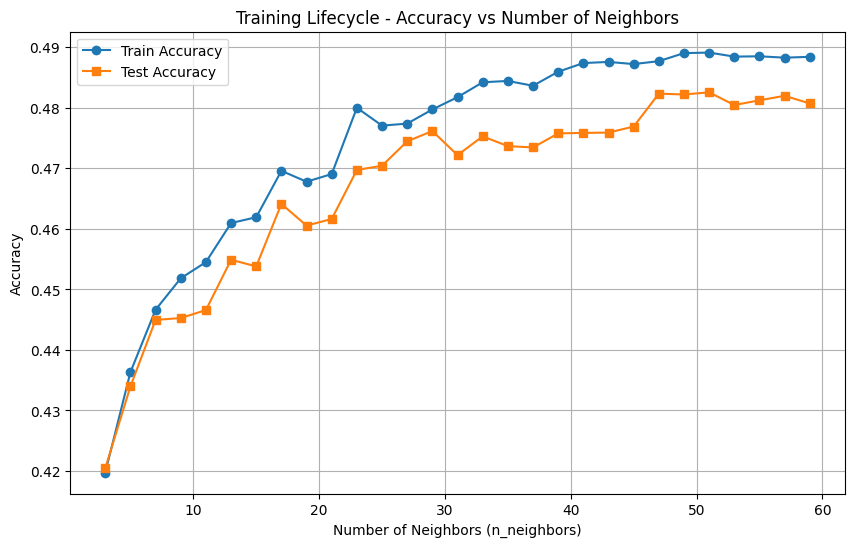

In [7]:
import matplotlib.pyplot as plt

# Load existing study from the database
study = optuna.load_study(
    study_name="knn_diseases_symptoms_dropextremelymore750withSMOTE_study",
    storage="sqlite:///C:/Users/khiew/Downloads/knn.db"
)

# 1. Create model with best parameters
best_params = study.best_trial.params
# ============================
# Simulate Training Lifecycle
# ============================

# We will vary `n_neighbors` to see how accuracy changes
n_neighbors_list = list(range(3, best_params['n_neighbors']+10, 2))  # Varying n_neighbors
train_accuracies = []
test_accuracies = []

for n in n_neighbors_list:
    model = KNeighborsClassifier(
        n_neighbors=n,
        weights=best_params['weights'],
        p=best_params['p']
    )
    
    model.fit(X_train_resampled, y_train_resampled)

    # Train accuracy
    y_train_pred = model.predict(X_train_resampled)
    train_acc = accuracy_score(y_train_resampled, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting the training lifecycle (Accuracy vs n_neighbors)
plt.figure(figsize=(10,6))
plt.plot(n_neighbors_list, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(n_neighbors_list, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('Training Lifecycle - Accuracy vs Number of Neighbors')
plt.legend()
plt.grid(True)
plt.show()